In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
df=pd.read_csv('CAMPUSX/DATASETS/Social_Network_Ads.csv')
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
# now this data looke bias so lets do random sample
df.sample(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
338,15810800,Female,38,55000,0
161,15670619,Male,25,90000,0
372,15629885,Female,39,73000,0
359,15709183,Male,42,54000,0
298,15675791,Male,45,79000,0


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    str  
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(4), str(1)
memory usage: 15.8 KB


In [6]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


iloc=index-based-selection


loc=label-based-selection , for multiple labels store labels in a list

In [7]:
df_selected=df.iloc[:,2:]
df_selected

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [8]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df_selected.drop('Purchased',axis=1),df_selected['Purchased'],test_size=0.3,random_state=0)
x_train.shape,y_train.shape,x_test.shape,y_test.shape

((280, 2), (280,), (120, 2), (120,))

Scaling the data (standardisation)

In [9]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(x_train)
x_train_scaled=scaler.transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [10]:
x_test_scaled

array([[-0.77101313,  0.49720103],
       [ 0.0133054 , -0.57280368],
       [-0.28081405,  0.15017248],
       [-0.77101313,  0.26584866],
       [-0.28081405, -0.57280368],
       [-1.06513258, -1.44037507],
       [-0.67297331, -1.5849703 ],
       [-0.18277423,  2.14558666],
       [-1.94749093, -0.05226085],
       [ 0.89566375, -0.775237  ],
       [-0.77101313, -0.60172273],
       [-0.96709276, -0.42820845],
       [-0.08473441, -0.42820845],
       [ 0.11134522,  0.20801057],
       [-1.7514113 ,  0.46828198],
       [-0.5749335 ,  1.36477242],
       [-0.08473441,  0.20801057],
       [-1.84945111,  0.43936294],
       [ 1.67998229,  1.74072002],
       [-0.28081405, -1.38253697],
       [-0.28081405, -0.65956082],
       [ 0.89566375,  2.14558666],
       [ 0.30742485, -0.54388463],
       [ 0.89566375,  1.01774386],
       [-1.45729185, -1.2090227 ],
       [ 1.09174339,  2.05882953],
       [-0.96709276,  0.49720103],
       [-0.86905295,  0.29476771],
       [-0.08473441,

In [11]:
x_trained_scale=pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_trained_scale.describe()

,Age,EstimatedSalary
count,2.800000e+02,2.800000e+02
mean,3.489272e-17,6.344132e-17
std,1.001791e+00,1.001791e+00
min,-1.947491e+00,-1.584970e+00
25%,-7.710131e-01,-7.752370e-01
50%,-8.473441e-02,2.003677e-02
75%,7.976239e-01,5.261201e-01
max,2.170181e+00,2.319101e+00


since the values we got above are very small to describe therefore we will scale the, to some decimal places

In [12]:
np.round(x_trained_scale.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


lets check the data after scaling and before scaling to notice if the data has changed 

Text(0.5, 1.0, 'after scaling')

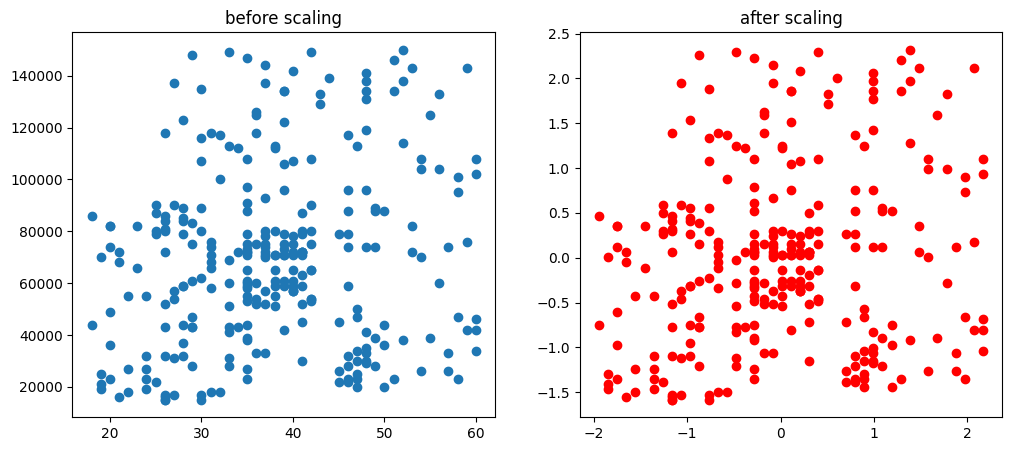

In [14]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

ax1.scatter(x_train['Age'],x_train['EstimatedSalary'])
ax1.set_title('before scaling')

ax2.scatter(x_trained_scale['Age'],x_trained_scale['EstimatedSalary'],color='red')
ax2.set_title('after scaling')

we can notice no visible change in dataset

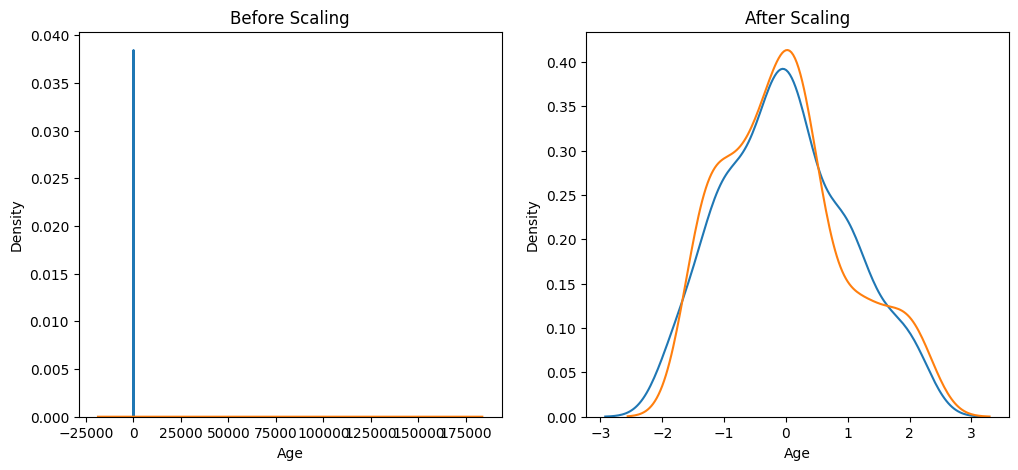

In [15]:
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize = (12,5))

ax1.set_title('Before Scaling')
sns.kdeplot(x_train['Age'],ax = ax1)
sns.kdeplot(x_train['EstimatedSalary'],ax = ax1)

ax2.set_title('After Scaling')
sns.kdeplot(x_trained_scale['Age'],ax = ax2)
sns.kdeplot(x_trained_scale['EstimatedSalary'],ax = ax2)

plt.show()

kde = kernel density estimation

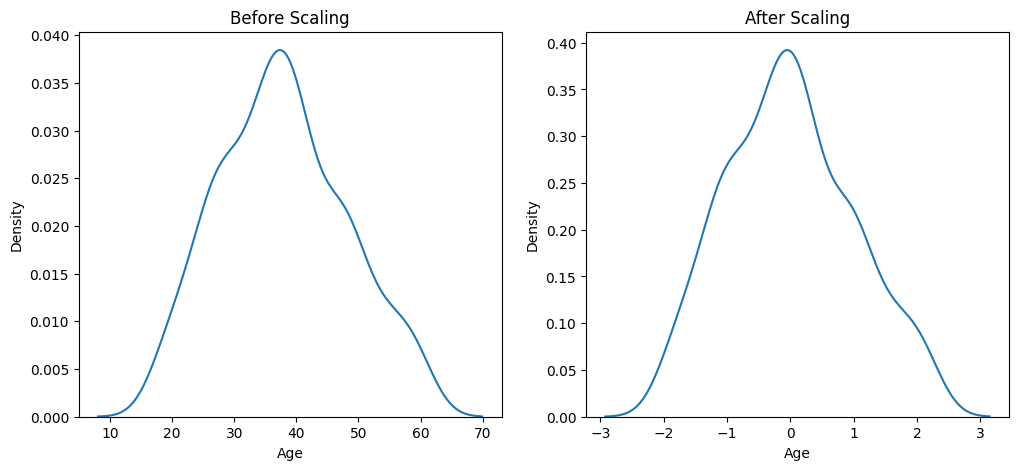

In [16]:
fig,(ax1,ax2) = plt.subplots(ncols = 2,figsize = (12,5))


ax1.set_title('Before Scaling')
sns.kdeplot(x_train['Age'],ax=ax1)
sns.kdeplot(x_trained_scale['Age'],ax=ax2)

ax2.set_title('After Scaling')
plt.show()

similary we can check for each column or group

WHY SCALING IS IMPORTANT 